In [2]:
from zipfile import ZipFile
import os

zip_file_path = '/content/drive/MyDrive/Deep-fashion-recommendation-system/de18b-women-fashion.zip'
extraction_directory = '/content/drive/MyDrive/Women Fashion'

if not os.path.exists(extraction_directory):
    os.makedirs(extraction_directory)

with ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_directory)

extracted_files = os.listdir(extraction_directory)
print(extracted_files[:10])

['women fashion', '__MACOSX']


Let’s ignore the macOS metadata and focus on the women fashion directory, listing its contents to understand the types and number of images we have:

In [3]:
# correcting the path to include the 'women fashion' directory and listing its contents
extraction_directory_updated = os.path.join(extraction_directory, 'women fashion')

# list the files in the updated directory
extracted_files_updated = os.listdir(extraction_directory_updated)
extracted_files_updated[:10], len(extracted_files_updated)

(['white knee-length dress with a fitted design and long sleeves.webp',
  'short, white, sleeveless dress with thin straps.jpg',
  'deep burgundy, silky dress with long sleeves and a wrap-style front.jpg',
  'long, intricately designed dress with full sleeves.jpg',
  'beige top adorned with black dots and a green skirt.jpg',
  'form-fitting dress with a vibrant pattern of yellow, blue, and black.jpg',
  'black top, white trousers.jpg',
  'ark green, knee-length dress with short sleeves and a white, patterned neckline.jpg',
  'metallic-looking jacket with intricate designs and fringes hanging from the sleeves.jpg',
  'anarkali suit with intricate silver embellishments on the neckline, sleeves.jpg'],
 97)

Now, let’s have a look at the first image from the dataset:

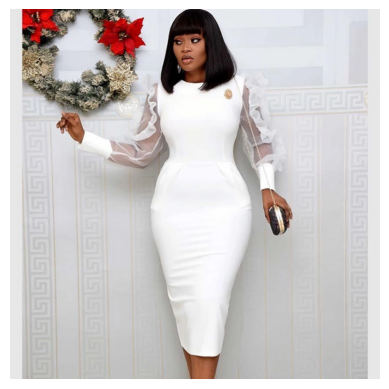

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

# function to load and display an image
def display_image(file_path):
    image = Image.open(file_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# display the first image to understand its characteristics
first_image_path = os.path.join(extraction_directory_updated, extracted_files_updated[0])
display_image(first_image_path)

Now, we will create a list of all image file paths that will be used later in extracting the features from every image in the dataset:

In [5]:
import glob

# directory path containing your images
image_directory = extraction_directory_updated


image_paths_list = [file for file in glob.glob(os.path.join(image_directory, '*.*')) if file.endswith(('.jpg', '.png', '.jpeg', 'webp'))]

# print the list of image file paths
print(image_paths_list)

['/content/drive/MyDrive/Women Fashion/women fashion/white knee-length dress with a fitted design and long sleeves.webp', '/content/drive/MyDrive/Women Fashion/women fashion/short, white, sleeveless dress with thin straps.jpg', '/content/drive/MyDrive/Women Fashion/women fashion/deep burgundy, silky dress with long sleeves and a wrap-style front.jpg', '/content/drive/MyDrive/Women Fashion/women fashion/long, intricately designed dress with full sleeves.jpg', '/content/drive/MyDrive/Women Fashion/women fashion/beige top adorned with black dots and a green skirt.jpg', '/content/drive/MyDrive/Women Fashion/women fashion/form-fitting dress with a vibrant pattern of yellow, blue, and black.jpg', '/content/drive/MyDrive/Women Fashion/women fashion/black top, white trousers.jpg', '/content/drive/MyDrive/Women Fashion/women fashion/ark green, knee-length dress with short sleeves and a white, patterned neckline.jpg', '/content/drive/MyDrive/Women Fashion/women fashion/metallic-looking jacket wi

In the above code, the glob module is used to generate a list of file paths for images stored in the directory. The glob.glob function searches for files that match a specified pattern, in this case, *.*, which matches all files within the directory. The list comprehension then filters these files to include only those with specific image file extensions (.jpg, .png, .jpeg, .webp).

It ensures that image_paths_list contains paths to only the image files, excluding any other file types that might be present in the directory.

Now, we will extract features from all the fashion images:

In [6]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
import numpy as np

base_model = VGG16(weights='imagenet', include_top=False)
model = Model(inputs=base_model.input, outputs=base_model.output)

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array_expanded = np.expand_dims(img_array, axis=0)
    return preprocess_input(img_array_expanded)

def extract_features(model, preprocessed_img):
    features = model.predict(preprocessed_img)
    flattened_features = features.flatten()
    normalized_features = flattened_features / np.linalg.norm(flattened_features)
    return normalized_features

all_features = []
all_image_names = []

for img_path in image_paths_list:
    preprocessed_img = preprocess_image(img_path)
    features = extract_features(model, preprocessed_img)
    all_features.append(features)
    all_image_names.append(img_path)   # keep FULL path



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 924ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 569ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 965ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 962ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 756ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In the above code, a feature extraction process is implemented using the VGG16 model, a popular convolutional neural network pre-trained on the ImageNet dataset, to extract visual features from images stored in image_paths_list.


Initially, the VGG16 model is loaded without its top classification layer (include_top=False), making it suitable for feature extraction rather than classification. Each image path from image_paths_list is processed through a series of steps: the image is loaded and resized to 224×224 pixels to match the VGG16 input size requirements, converted to a NumPy array, and preprocessed to fit the model’s expected input format.

The preprocessed images are then fed into the VGG16 model to extract features, which are subsequently flattened and normalized to create a consistent feature vector for each image. These feature vectors (all_features) and their corresponding image filenames (all_image_names) are stored, providing a structured dataset for the next steps in building a fashion recommendation system using image features.

Now, I’ll write a function to recommend fashion images based on image features:

In [7]:
from scipy.spatial.distance import cosine

def recommend_fashion_items_cnn(input_image_path, all_features, all_image_names, model, top_n=5):
    preprocessed_img = preprocess_image(input_image_path)
    input_features = extract_features(model, preprocessed_img)

    similarities = [1 - cosine(input_features, other_feature) for other_feature in all_features]

    # sort in descending order (most similar first)
    similar_indices = np.argsort(similarities)[::-1]

    # remove input image + take top_n
    similar_indices = [
        idx for idx in similar_indices
        if all_image_names[idx] != input_image_path
    ][:top_n]

    plt.figure(figsize=(15, 10))

    # input image
    plt.subplot(1, top_n + 1, 1)
    plt.imshow(Image.open(input_image_path))
    plt.title("Input Image")
    plt.axis('off')

    # recommendations
    for i, idx in enumerate(similar_indices, start=1):
        plt.subplot(1, top_n + 1, i + 1)
        plt.imshow(Image.open(all_image_names[idx]))
        plt.title(f"Recommendation {i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


In the above code, we defined a function recommend_fashion_items_cnn, which recommends fashion items similar to a given input image using deep learning-based feature extraction. It utilizes the VGG16 model to extract high-dimensional feature vectors from images, capturing their visual essence.

For a specified input image,
* the function preprocesses the image, extracts its features,
* calculates the cosine similarity between this feature vector and those of other images in the dataset (all_features).
* It ranks these images based on similarity and selects the top N most similar images to recommend, explicitly excluding the input image from being recommended to itself by filtering out its index from the list of similar indices.

In the end, the function will visualize the input image and its recommendations by displaying them.

Now, here’s how we can use this function to recommend images based on a similar fashion in the input image:

# You need to give the path of an image as an input, and you will see similar fashion recommendations as output.

In [8]:
input_image_path = '/content/drive/MyDrive/Women Fashion/women fashion/anarkali suit with a long, olive green kurta adorned with intricate embroidery around the neckline and cuffs, paired with matching fitted trousers.jpg'



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 983ms/step


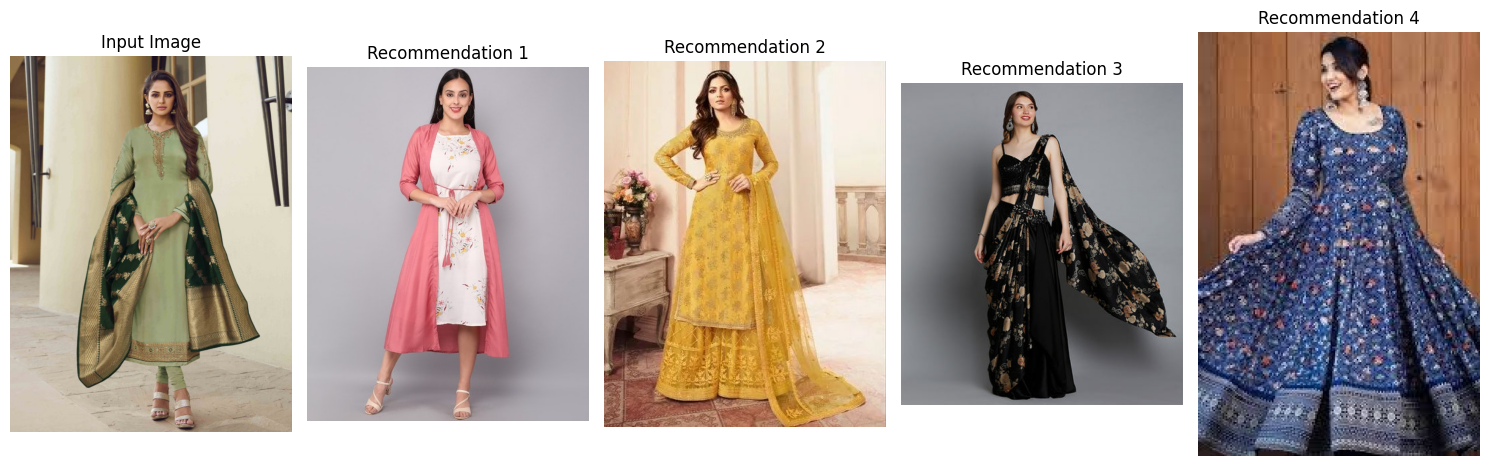

In [9]:
recommend_fashion_items_cnn(input_image_path, all_features, all_image_names, model, top_n=4)

In [10]:
import pickle

pickle.dump(all_features, open('features.pkl', 'wb'))
pickle.dump(all_image_names, open('filenames.pkl', 'wb'))
